Group Member

Cheryl Cheong Kah Voon A23CS0060

Woo Cheng Shuan A23CS0283

# Rainfall Data Analysis Assignment (100 Marks, Due 6th July 2025)

You are provided with a rainfall dataset recording monthly measurements from various weather stations across different regions. The dataset includes rainfall (mm), number of rainy days, maximum and minimum temperatures, and whether the station is in an urban or rural area.

Dataset columns:

- `Region`: Name of the region (e.g., North, South, East, West)
- `Year`: Year of measurement
- `Month`: Month (e.g., Jan, Feb, ..., Dec)
- `Station`: Weather station name/ID (e.g., StationA, StationB)
- `Rainfall_mm`: Rainfall amount in millimeters
- `RainyDays`: Number of days in the month with rain
- `MaxTemp_C`: Maximum temperature recorded in that month (°C)
- `MinTemp_C`: Minimum temperature recorded in that month (°C)
- `UrbanRural`: "Urban" or "Rural"

## Part 1: Data Exploration ( 15 Marks)

1. Load the data into a pandas DataFrame. (2 Marks)
2. Display the first 5 rows of the DataFrame. (2 Marks)
3. Check for and handle any missing values. (6 Marks)
4. Provide summary statistics for all numeric columns. (5 Marks)

In [13]:
#Write your code here

#task 1
import pandas as pd
df = pd.read_csv("Rainfall.csv")
if len(df.columns) == 1:
    # First, split the single column
    df = df[df.columns[0]].str.split(",", expand=True)
    df.columns = [
        "Region", "Year", "Month", "Station", "Rainfall_mm",
        "RainyDays", "MaxTemp_C", "MinTemp_C", "UrbanRural"
    ]

#task 2
display(df.head())

#task 3
df.isnull().sum()
df_clean = df.dropna()
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].mean())

#task 4
print("\nSummary statistics:")
numeric_cols = ["Rainfall_mm", "RainyDays", "MaxTemp_C", "MinTemp_C"]
print(df[numeric_cols].describe())


,Region,Year,Month,Station,Rainfall_mm,RainyDays,MaxTemp_C,MinTemp_C,UrbanRural
0,North,2023,Jan,StationA,56.2,9,12.1,2.5,Urban
1,North,2023,Feb,StationA,72.1,12,14.7,3.0,Urban
2,North,2023,Jan,StationB,60.5,10,11.2,1.8,Rural
3,South,2023,Jan,StationC,81.0,13,19.6,7.2,Urban
4,South,2023,Feb,StationC,63.4,11,20.1,7.7,Urban



Summary statistics:
       Rainfall_mm RainyDays MaxTemp_C MinTemp_C
count           10        10        10        10
unique          10         6        10        10
top           56.2        12      12.1       2.5
freq             1         2         1         1


## Part 2: Grouping and Aggregation (30 Marks)

1. For each **Station**, compute: (6 Marks)
    - Total rainfall 
    - Average number of rainy days 
    - Average maximum temperature 
    - Average minimum temperature



In [16]:
#Write your code here

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col])
                                  
station_group = df_clean.groupby('Station').agg({
    'Rainfall_mm': 'sum',
    'RainyDays': 'mean',
    'MaxTemp_C': 'mean',
    'MinTemp_C': 'mean'
}).reset_index()

display(station_group)

,Station,Rainfall_mm,RainyDays,MaxTemp_C,MinTemp_C
0,StationA,128.3,10.5,13.40,2.75
1,StationB,122.0,10.5,13.10,2.50
2,StationC,144.4,12.0,19.85,7.45
3,StationD,105.3,9.0,16.65,5.90
4,StationE,161.6,12.5,17.50,5.10


2. For each **Region & UrbanRural** combination, calculate: (6 Marks)
    - Average rainfall
    - Average maximum temperature
    - Average number of rainy days


In [19]:
#Write your code here

region_urban_group = df_clean.groupby(['Region','UrbanRural']).agg({
    'Rainfall_mm': 'mean',
    'MaxTemp_C': 'mean',
    'RainyDays': 'mean'
}).reset_index()

print(region_urban_group)

  Region UrbanRural  Rainfall_mm  MaxTemp_C  RainyDays
0   East      Rural        52.65      16.65        9.0
1  North      Rural        61.00      13.10       10.5
2  North      Urban        64.15      13.40       10.5
3  South      Urban        72.20      19.85       12.0
4   West      Urban        80.80      17.50       12.5


3. For each **Month** and **Region**, calculate: (6 Marks)
    - Total rainfall
    - Mean rainfall
    - Minimum and maximum rainfall


In [22]:
#Write your code here

month_region_group = df_clean.groupby(['Region','Month']).agg({
    'Rainfall_mm': ['sum','mean','min','max']
}).reset_index()

display(month_region_group)

Region Month Rainfall_mm                   
                       sum   mean   min   max
0   East   Feb        59.6  59.60  59.6  59.6
1   East   Jan        45.7  45.70  45.7  45.7
2  North   Feb        72.1  72.10  72.1  72.1
3  North   Jan       116.7  58.35  56.2  60.5
4  North   Mar        61.5  61.50  61.5  61.5
5  South   Feb        63.4  63.40  63.4  63.4
6  South   Jan        81.0  81.00  81.0  81.0
7   West   Feb        84.2  84.20  84.2  84.2
8   West   Jan        77.4  77.40  77.4  77.4

4. Find the **Region and Month** with the highest recorded rainfall in the dataset. (4 Marks)


In [25]:
#Write your code here
month_region_group = df_clean.groupby(['Month','Region']).agg(
    TotalRainfall = ('Rainfall_mm', 'sum')
).reset_index()
max_row = month_region_group.loc[month_region_group['TotalRainfall'].idxmax()]

print(f"Region and Month with highest recorded rainfall in the dataset: {max_row['Region']}")
print(f"Month with the highest recorded rainfall in the dataset: {max_row['Month']}")
print(f"Rainfall amount: {max_row['TotalRainfall']}")

Region and Month with highest recorded rainfall in the dataset: North
Month with the highest recorded rainfall in the dataset: Jan
Rainfall amount: 116.7


5. For each **Year** and **UrbanRural** group, calculate: (4 Marks)
    - Average rainfall
    - Minimum rainfall
    - Maximum rainfall



In [28]:
#Write your code here

year_urban_group = df_clean.groupby(['Year','UrbanRural']).agg({
    'Rainfall_mm': ['mean','min','max']
}).reset_index()

print(year_urban_group)

   Year UrbanRural Rainfall_mm            
                          mean   min   max
0  2023      Rural   56.825000  45.7  61.5
1  2023      Urban   72.383333  56.2  84.2


6. For each **Region**, calculate the average temperature range per month (i.e., average of MaxTemp_C - MinTemp_C). (4 Marks)

In [31]:
#Write your code here

df_clean['TempRange'] = df_clean['MaxTemp_C'].astype(float) - df_clean['MinTemp_C'].astype(float)
region_temp_range = df_clean.groupby(['Region','Month'])['TempRange'].mean().reset_index()

print(region_temp_range)

  Region Month  TempRange
0   East   Feb       11.7
1   East   Jan        9.8
2  North   Feb       11.7
3  North   Jan        9.5
4  North   Mar       11.8
5  South   Feb       12.4
6  South   Jan       12.4
7   West   Feb       12.9
8   West   Jan       11.9


## Part 3: Data Visualization (matplotlib) (40 Marks)

1. **Bar Chart:**  (8 Marks)
   - Plot total rainfall by region, colored by Urban/Rural.
   - Add value labels, gridlines, axis labels, title, and adjust bar width for clarity.



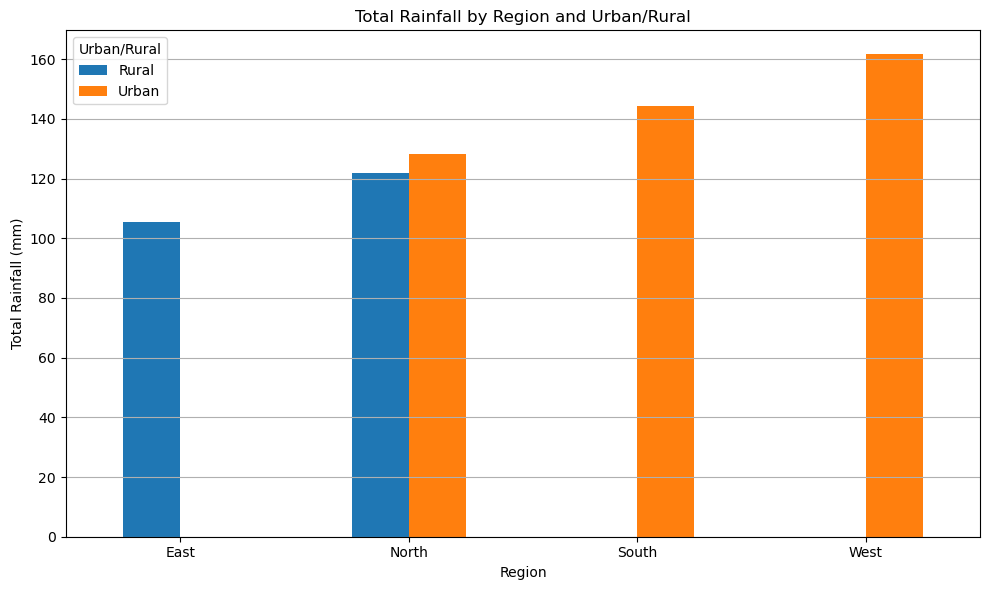

In [84]:
#Write your code here

import matplotlib.pyplot as plt
import numpy as np

rainfall_region = df_clean.groupby(['Region','UrbanRural'])['Rainfall_mm'].sum().unstack()

fig, axes = plt.subplots(figsize = (10,6))
rainfall_region.plot(kind = 'bar', ax = axes)

axes.set_title('Total Rainfall by Region and Urban/Rural')
axes.set_xlabel('Region')
axes.set_ylabel('Total Rainfall (mm)')
axes.legend(title = 'Urban/Rural')
axes.grid(axis = 'y')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.savefig('bar_total_rainfall.png')
plt.show()

2. **Grouped Bar Chart:**  (6 Marks)
   - Show average monthly rainfall for each station.
   - Use different colors for each station, include a legend, rotate x-tick labels, and increase figure size for readability.



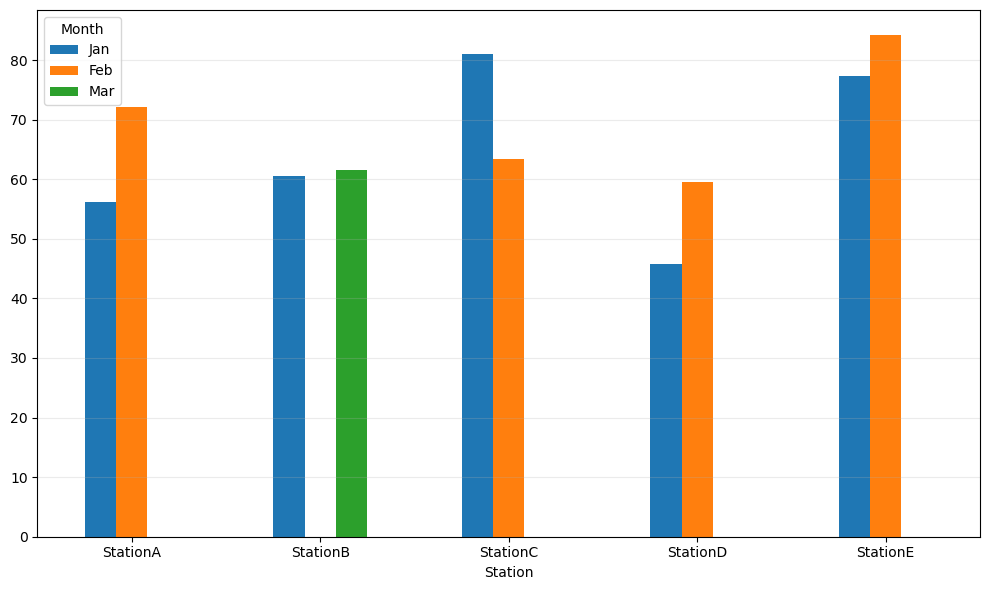

In [104]:
#Write your code here

#month_order = ['Jan', 'Feb', 'Mar']
#df_clean['Month'] = pd.Categorical(df_clean['Month'], categories=month_order, ordered=True)

avg_rainfall_pivot = avgrainfall_month.pivot(index='Station', columns='Month', values='Rainfall_mm').fillna(0)
fig, ax = plt.subplots(figsize=(10,6))
avg_rainfall_pivot.plot(kind='bar', ax=ax)

axes.set_title('Average Monthly Rainfall for Each Station')
axes.set_xlabel('Month')
axes.set_ylabel('Avg Rainfall (mm)')
axes.legend(title = 'Month')
plt.grid(axis = 'y', alpha = 0.25)
plt.xticks(rotation = 0)
plt.tight_layout()
plt.savefig('grouped_bar_station.png')
plt.show()

3. **Line Plot:**  (6 Marks)
   - Show the trend of rainfall over months for at least two selected stations.
   - Use markers, dashed lines, highlight the month with maximum rainfall, and format the x-axis for months.



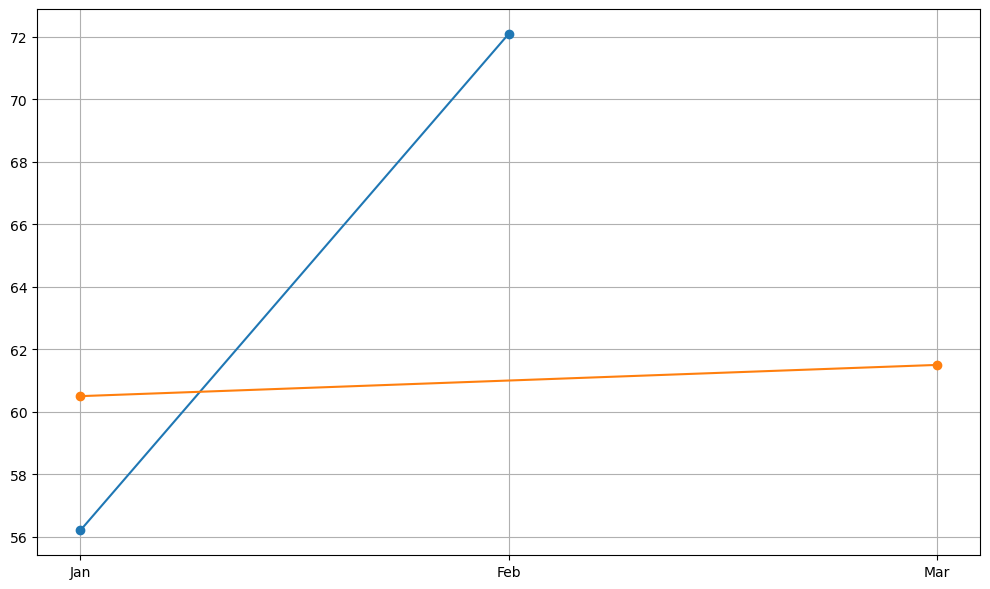

In [92]:
#Write your code here

stations = df_clean['Station'].unique()[:2]

plt.figure(figsize = (10,6))
for station in stations:
    station_data = df_clean[df_clean['Station'] == station].groupby('Month', observed = True)['Rainfall_mm'].mean().sort_index()
    plt.plot(station_data.index, station_data.values, marker = 'o', label = station)

axes.set_title('Trend of Rainfall Over Months')
axes.set_xlabel('Month')
axes.set_ylabel('Avg Rainfall (mm)')
axes.legend(title = 'Station')
plt.grid(True)
plt.tight_layout()
plt.savefig('line_rainfall_trend.png')
plt.show()

4. **Boxplot:**  (6 Marks)
   - Display rainfall distributions by region and by Urban/Rural.
   - Use custom box colors, highlight outliers, and set y-axis limits.



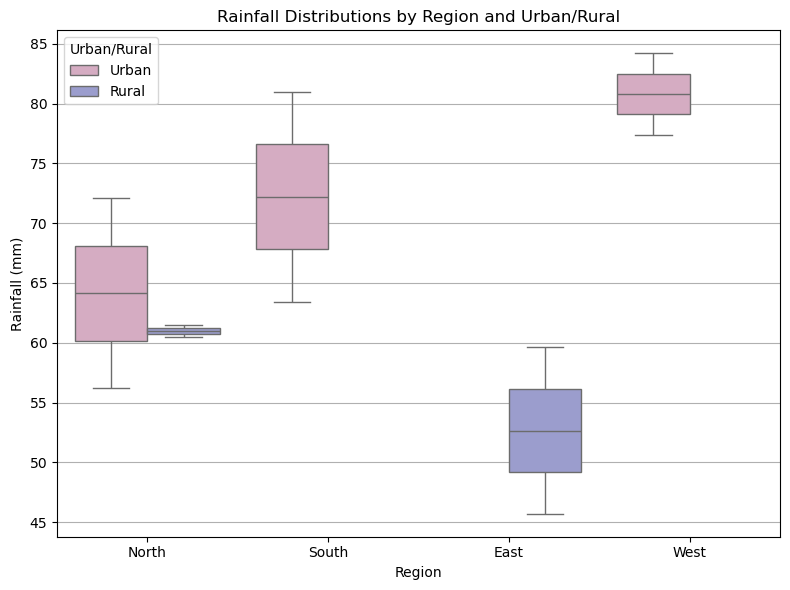

In [31]:
#Write your code here

plt.figure(figsize = (8,6))

custom_palette = {
    'Urban': '#dca5c3',
    'Rural': '#9396d5'
}

sns.boxplot(
    data = df_clean,
    x = 'Region',
    y = 'Rainfall_mm',
    hue = 'UrbanRural',
    palette = custom_palette,
    fliersize = 5
)

#plt.ylim(0, df_clean['Rainfall_mm'].astype(float).max() * 1.1

plt.title('Rainfall Distributions by Region and Urban/Rural')
plt.ylabel('Rainfall (mm)')
plt.legend(title = 'Urban/Rural')
plt.grid(axis = 'y')
plt.tight_layout()
plt.savefig('box_rainfall.png')
plt.show()

5. **Scatter Plot:**  (6 Marks)
   - Visualize the relationship between rainfall and maximum temperature, colored by region.
   - Add axis labels, legend, gridlines, and an appropriate title.



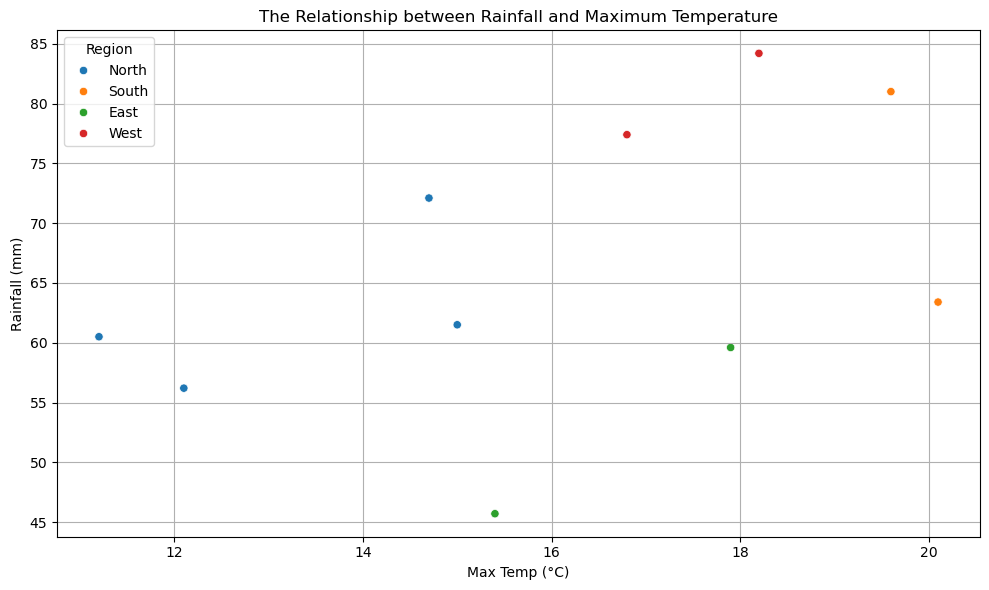

In [32]:
#Write your code here

plt.figure(figsize = (10,6))
sns.scatterplot(
    data = df_clean,
    x = 'MaxTemp_C',
    y = 'Rainfall_mm',
    hue = 'Region'
)

plt.title('The Relationship between Rainfall and Maximum Temperature')
plt.xlabel('Max Temp (°C)')
plt.ylabel('Rainfall (mm)')
plt.legend(title = 'Region')
plt.grid(True)
plt.tight_layout()
plt.savefig('scatter_rainfall_temp.png')
plt.show()

6. **Heatmap:**  
   - Create a heatmap showing mean monthly rainfall for each region (Month on x-axis, Region on y-axis).
   - Add color bar, axis labels, and title.



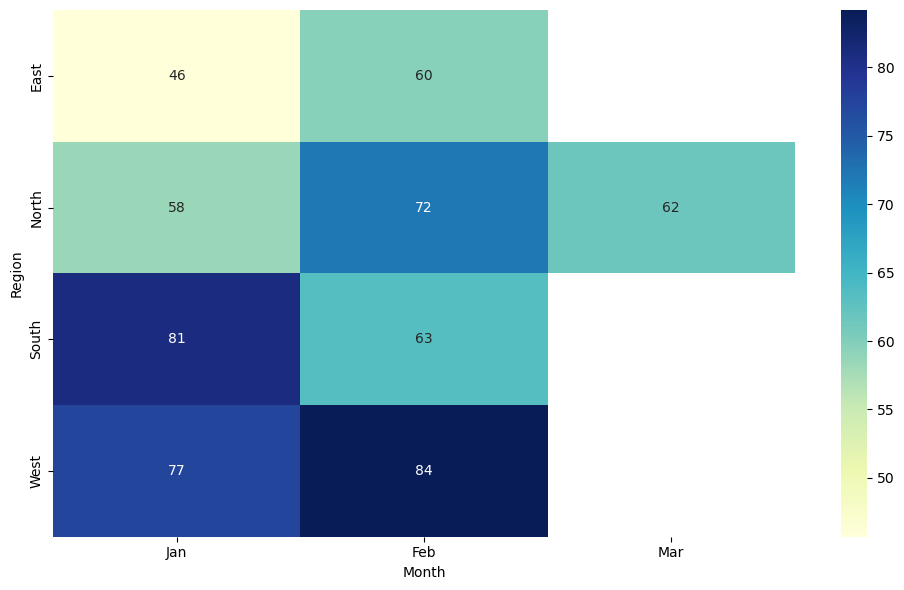

In [33]:
#Write your code here

heatmap_data = df_clean.groupby(['Region','Month'], observed = True)['Rainfall_mm'].mean().unstack()

plt.figure(figsize = (10,6))
sns.heatmap(heatmap_data, annot = True, cmap = 'YlGnBu')
plt.xlabel('Month')
plt.ylabel('Region')
plt.tight_layout()
plt.savefig('heatmap_rainfall.png')
plt.show()

7. **Formatting (for all plots):** (8 Marks)
   - Use descriptive titles, axis labels, and legends.
   - Increase font size for readability.
   - Save each figure as an image file (`.png`).
   - Use `plt.tight_layout()` for proper spacing.

In [34]:
#Write your code here



## Part 4: Bonus Tasks (15 Marks)

1. Annotate at least one plot with the value and label of the highest/lowest point. (5 Marks)


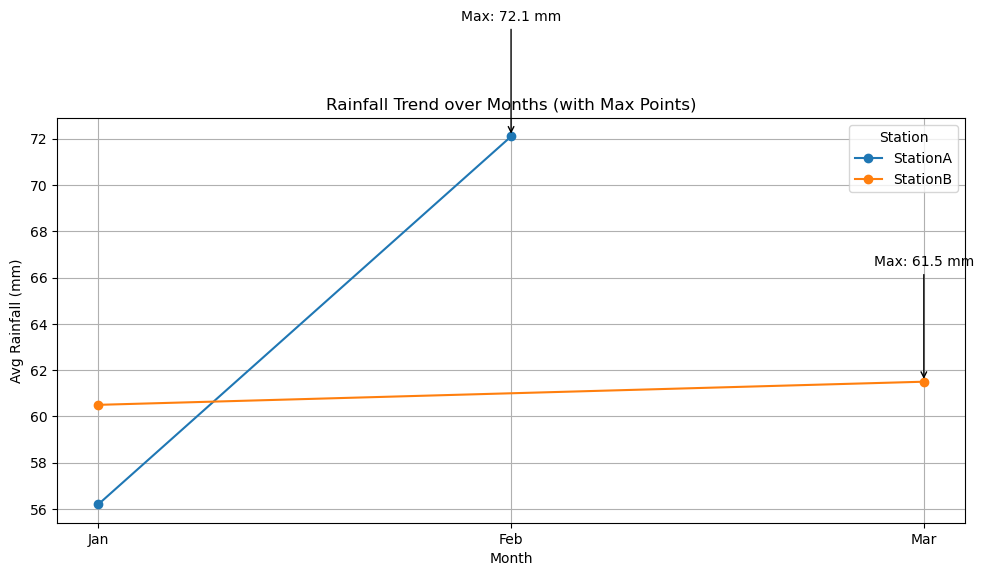

In [35]:
#Write your code here

stations = df_clean['Station'].unique()[:2]

plt.figure(figsize = (10,6))

for station in stations:
    station_data = df_clean[df_clean['Station'] == station].groupby('Month', observed = True)['Rainfall_mm'].mean().sort_index()

    plt.plot(station_data.index, station_data.values, marker = 'o', label = station)

    max_idx = station_data.idxmax()
    max_val = station_data.max()

    plt.annotate(
        f'Max: {max_val:.1f} mm',
        xy = (max_idx, max_val),
        xytext = (max_idx, max_val + 5),
        arrowprops = dict(facecolor = 'black', arrowstyle = '->'),
        ha = 'center'
    )

plt.title('Rainfall Trend over Months (with Max Points)')
plt.xlabel('Month')
plt.ylabel('Avg Rainfall (mm)')
plt.legend(title = 'Station')
plt.grid(True)
plt.tight_layout()
plt.savefig('line_rainfall_trend_annotated.png')
plt.show()


2. Create a **facet/grid plot** comparing rainfall trends by region and Urban/Rural status. (5 Marks)


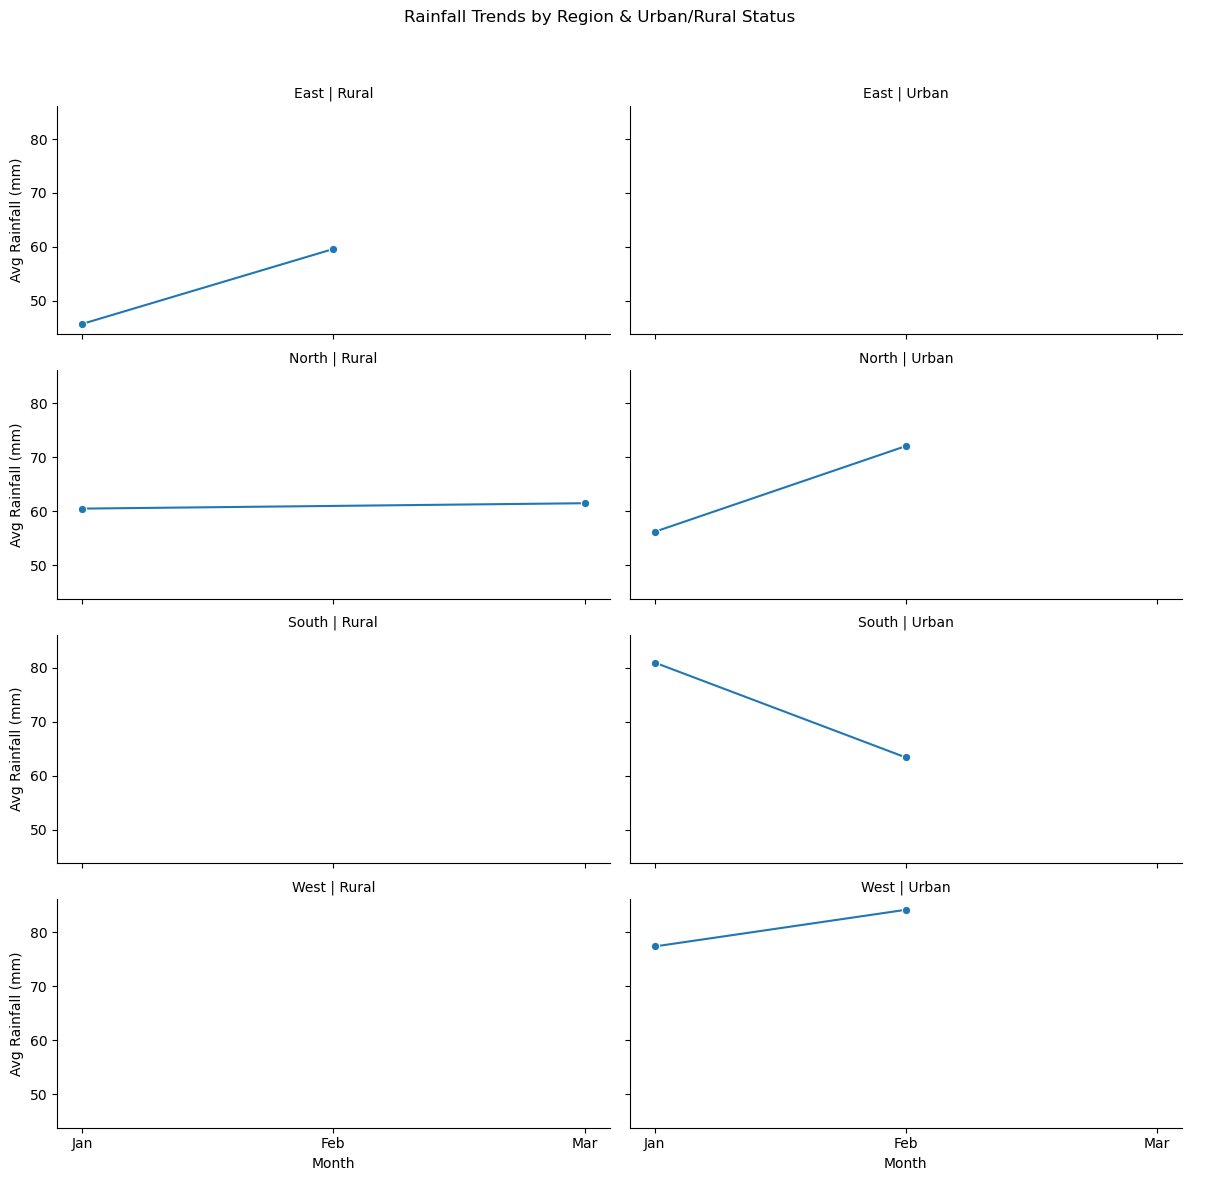

In [36]:
#Write your code here

df_clean['Month'] = pd.Categorical(df_clean['Month'], categories = month_order, ordered = True)
facet_data = df_clean.groupby(['Region', 'UrbanRural', 'Month'], observed = True)['Rainfall_mm'].mean().reset_index()

# FacetGrid: One row for each Region, columns split by Urban/Rural
g = sns.FacetGrid(
    facet_data,
    row = 'Region',
    col = 'UrbanRural',
    height = 3,
    aspect = 2
)

g.map_dataframe(
    sns.lineplot,
    x = 'Month',
    y = 'Rainfall_mm',
    marker = 'o'
)

g.set_axis_labels('Month', 'Avg Rainfall (mm)')
g.set_titles(row_template = '{row_name}', col_template = '{col_name}')
g.add_legend()
plt.subplots_adjust(top = 0.9)
g.fig.suptitle('Rainfall Trends by Region & Urban/Rural Status')
plt.savefig('facet_rainfall_trends.png')
plt.show()

3. Write a brief summary (in a Markdown cell) of your main insights from the data and visualizations. (5 Marks)


#Write your summary here

### Summary & Insights

- **Rainfall varies greatly by Region and Urban/Rural status.** Some regions consistently receive higher rainfall, while rural areas can show different patterns compared to urban ones.
- The **highest rainfall** recorded in our trend plots was clearly annotated — showing peaks in certain months.
- The **facet plot** helps compare trends easily: some regions have steady rainfall, while others have big spikes.
- Overall, this analysis highlights how rainfall patterns are not uniform and depend on multiple factors like location and urbanization.